In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# For visualization
import seaborn as sns

In [2]:
#Generate synthetic data for two classes
np.random.seed(42)

# Class 0: 'Sweet-Crunchy' (e.g., Apples)
X0 = np.random.normal(loc=[5, 5], scale=[1, 1], size=(50, 2))
y0 = np.zeros(50)

# Class 1: 'Sweet-Soft' (e.g., Pears)
X1 = np.random.normal(loc=[7, 3], scale=[1, 1], size=(50, 2))
y1 = np.ones(50)

# Combine data
X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

df = pd.DataFrame(X, columns=['Sweetness', 'Crunchiness'])
df['Class'] = y

display(df.head())

,Sweetness,Crunchiness,Class
0,5.496714,4.861736,0.0
1,5.647689,6.523030,0.0
2,4.765847,4.765863,0.0
3,6.579213,5.767435,0.0
4,4.530526,5.542560,0.0


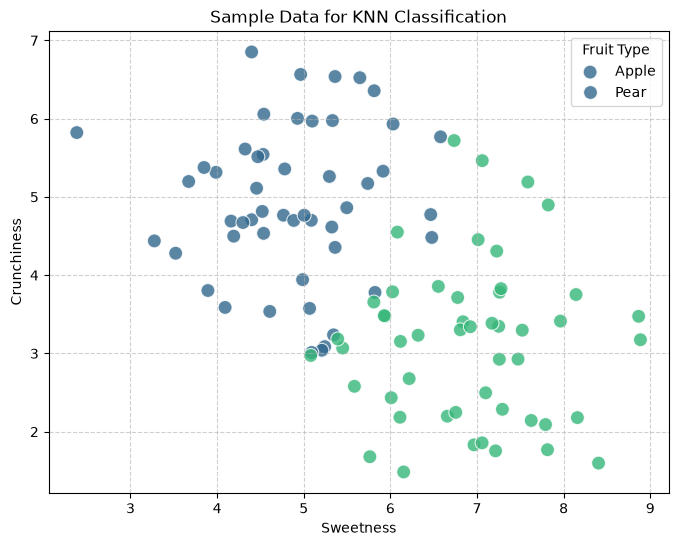

In [3]:
# Plot the generated data
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Sweetness', y='Crunchiness', hue='Class', data=df, palette='viridis', s=100, alpha=0.8)
plt.title('Sample Data for KNN Classification')
plt.xlabel('Sweetness')
plt.ylabel('Crunchiness')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Fruit Type', loc='upper right', labels=['Apple', 'Pear'])
plt.show()

In [4]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (70, 2), (70,)
Testing set shape: (30, 2), (30,)


In [5]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training features (first 5 rows):\n", X_train_scaled[:5])

Scaled training features (first 5 rows):
 [[-0.70202462 -0.32807818]
 [-1.06108645 -0.35749633]
 [ 0.11271985 -1.38368519]
 [-1.41036236  0.51844579]
 [ 1.17728369 -0.81987402]]


In [6]:
# Initialize KNN classifier with k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_scaled, y_train)

print("KNN model trained successfully with k=5.")

KNN model trained successfully with k=5.


In [7]:
# Make predictions on the scaled test data
y_pred = knn.predict(X_test_scaled)

print("First 10 actual labels:", y_test[:10])
print("First 10 predicted labels:", y_pred[:10])

First 10 actual labels: [1. 1. 1. 0. 0. 0. 0. 1. 0. 0.]
First 10 predicted labels: [1. 1. 1. 0. 0. 0. 0. 1. 0. 0.]


In [8]:
# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.97
